In [1]:
%cd ~/Code/naam

%load_ext autoreload
%autoreload 2


import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
import torch
import ipywidgets as widgets
from tqdm import tqdm
import subprocess

import random
from datasets import load_dataset
import IPython.display as ipd


from naam import models


import librosa
import librosa.display
from scipy.io.wavfile import write
from skimage.transform import resize

import random

# Step 1: Check for GPU availability
if torch.cuda.is_available():
    device = torch.device("cuda")  # Use the first CUDA device
    print("Using GPU:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")  # Fallback to CPU if GPU is not available
    print("GPU is not available, using CPU instead.")

/u/leokoz8/Code/naam
Using GPU: Tesla V100-SXM2-32GB


In [2]:


def generate_random_binary_spectrogram(fs=44100, duration=10, width=128, height=128, density=0.5):
    """
    Generate an audio signal whose spectrogram looks like a random binary image.

    Each pixel (row, column) corresponds to a frequency (row) present
    or absent during a small time slice (column). A '1' in the binary 
    image indicates the frequency is present (added as a sine wave),
    while a '0' indicates silence (for that frequency).

    Parameters:
        fs (int): Sampling rate in Hz (default: 44100).
        duration (float): Total duration of the audio in seconds (default: 10).
        width (int): Number of columns (time slices) in the binary "image".
        height (int): Number of rows (frequency bins) in the binary "image".
        density (float): The probability of a pixel being '1' 
                         (0 => no notes, 1 => all notes).
                         Default is 0.5.

    Returns:
        str: The filename of the generated audio, 'random_binary_spectrogram.wav'.
    """

    # Generate a random binary image of shape (height, width)
    # with probability 'density' of being 1
    random_image = (np.random.rand(height, width) < density).astype(int)

    # Define the time axis for the entire audio
    total_samples = int(fs * duration)
    t = np.linspace(0, duration, total_samples, endpoint=False)

    # Prepare an empty signal buffer
    signal = np.zeros(total_samples, dtype=np.float64)

    # Time slice duration for each column
    time_per_column = duration / width

    # Frequency range (you can adjust this as you like)
    freq_min = 200.0   # Hz
    freq_max = 4000.0  # Hz

    # For amplitude scaling
    amplitude_scale = 1.0 / np.sqrt(height)

    # Go column by column (time slice by time slice)
    for col in range(width):
        # Start and end indices in the time domain for this column
        start_idx = int(col * time_per_column * fs)
        end_idx = int((col + 1) * time_per_column * fs)

        # Extract the time segment relevant for this column
        t_segment = t[start_idx:end_idx]

        # For each row (frequency bin)
        for row in range(height):
            if random_image[row, col] == 1:
                # Map row index to a frequency in [freq_min, freq_max]
                freq = freq_min + (freq_max - freq_min) * (row / (height - 1))

                # Add a sine wave for the duration of this column
                signal[start_idx:end_idx] += amplitude_scale * np.sin(2 * np.pi * freq * t_segment)

    # Normalize the entire signal to avoid clipping
    max_val = np.max(np.abs(signal))
    if max_val > 0:
        signal = signal / max_val

    # Save to a .wav file
    filename = "random_binary_spectrogram.wav"
    write(filename, fs, (signal * 32767).astype(np.int16))

    return filename



def get_binary_spectrogram_from_audio(filename='decreasing_bands.wav',plot = False):
    """
    Load an audio file and generate a binary spectrogram.
    """
    # Load the generated audio file
    y, sr = librosa.load(filename, sr=None)
    
    # Compute the spectrogram
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=100, fmax=1000)
    
    # Convert to dB scale
    S_db = librosa.power_to_db(S, ref=np.max)
    
    # Binarize using a threshold
    binary_S = S_db > -20  # Adjust threshold as needed
    
    # Resize to ensure the total number of pixels is ≤ 1e4
    target_size = (int(np.sqrt(1e3)), int(np.sqrt(1e3)))  # Approximate square shape
    S_resized = resize(S_db, target_size, anti_aliasing=False, mode='constant')
    binary_S_resized = resize(binary_S, target_size, anti_aliasing=False, mode='constant')

    if plot:
        # Display binary spectrogram
        plt.figure(figsize=(8, 6))
        plt.imshow(binary_S_resized, cmap='gray', aspect='auto', origin='lower')
        plt.title("Binarized Spectrogram")
        plt.xlabel("Time")
        plt.ylabel("Mel Frequency")
        plt.colorbar(label="Binary Intensity")
        plt.show()

    return S_resized, binary_S_resized

# Generate audio and process spectrogram



def generate_binary_spec_torch(density,device = 'cpu', plot = False):
    
    audio_file = generate_random_binary_spectrogram(density = density)
    _, binary_S_resized = get_binary_spectrogram_from_audio(audio_file,plot)

    tmp = 2*torch.tensor(binary_S_resized, dtype = float) - 1
    tmp = tmp.flatten().unsqueeze(1)
    

    
    return tmp.to(device), audio_file


In [6]:
binary_spec_1,_ = generate_binary_spec_torch(density = 0.2, device = device, plot = False)
binary_spec_2,audio_file = generate_binary_spec_torch(density = 0.03, device = device,plot = False)

etas = torch.concatenate((binary_spec_1,binary_spec_2),1)

print("Storing and retriving memories...")
x, S, P, initial_distance, final_distance,x0 = models.integrate_dynamics(N=etas.shape[0], K = etas.shape[1], NUM_STEPS=int(1e3), dt=0.1, beta=5, corruption_level=0.3, 
                        etas=etas, memory_to_seed_from=1, device=device)

Storing and retriving memories...


100%|██████████████████████████████████████| 1000/1000 [00:01<00:00, 873.82it/s]

Initial L2 distance of neural state to memory 1 is 34.058772731852805
Final L2 distance of neural state to memory 1 is 0.0


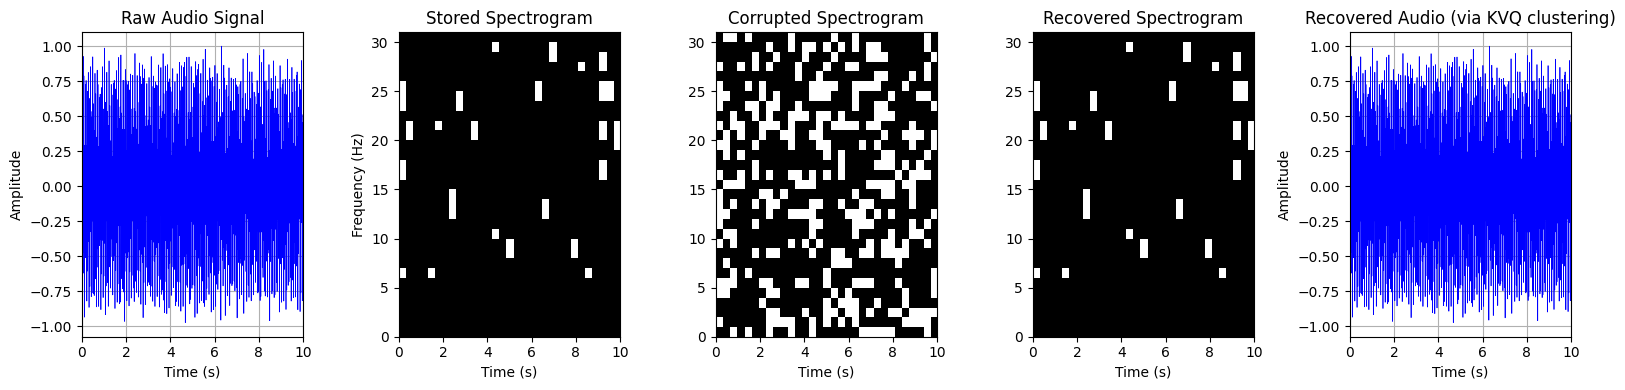

In [23]:
import librosa
import numpy as np
import torch
import matplotlib.pyplot as plt

# Generate the audio file
audio_file = generate_random_binary_spectrogram()

# Load the raw audio signal
y, sr = librosa.load(audio_file, sr=None)

# Create the time axis
time = np.linspace(0, len(y) / sr, num=len(y))

def convert_hopfield_output_to_image(tensor):
    """
    Convert the Hopfield network output (1D tensor) into a 2D NumPy array 
    suitable for plotting with imshow (e.g., a binary image).
    """
    # Binarize using sign, mapping from {-1, +1} to {0, 1}
    tmp = (torch.sign(tensor) + 1) / 2

    # Assume a square image (side_length x side_length)
    side_length = int(np.sqrt(tmp.shape[0]))
    tmp = tmp.reshape(side_length, side_length)

    # Detach from the graph and move to CPU (if it's on GPU)
    tmp = tmp.detach().cpu().numpy()

    return tmp

# Convert Hopfield output to images
img0 = convert_hopfield_output_to_image(binary_spec_2)
img1 = convert_hopfield_output_to_image(x0)
img2 = convert_hopfield_output_to_image(x)

# Define figure and axes
fig, axes = plt.subplots(1, 5, figsize=(16, 4), sharex=True)

# Plot raw audio signal
axes[0].plot(time, y, linewidth=0.5, color='b')
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")
axes[0].set_title("Raw Audio Signal")
axes[0].grid(True)

# Set extent for images
side_length = img1.shape[1]
extent = [0, time[-1], 0, side_length]  # Ensure x-axis matches the time axis

# Plot stored spectrogram
axes[1].imshow(img0, cmap='gray', aspect='auto', origin='lower', extent=extent)
axes[1].set_title('Stored Spectrogram')
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Frequency (Hz)")

# Plot corrupted spectrogram
axes[2].imshow(img1, cmap='gray', aspect='auto', origin='lower', extent=extent)
axes[2].set_title('Corrupted Spectrogram')
axes[2].set_xlabel("Time (s)")

# Plot recovered spectrogram
axes[3].imshow(img2, cmap='gray', aspect='auto', origin='lower', extent=extent)
axes[3].set_title('Recovered Spectrogram')
axes[3].set_xlabel("Time (s)")

# Plot recovered spectrogram

axes[4].set_title('Recovered Audio (via KVQ clustering)')
axes[4].plot(time, y, linewidth=0.5, color='b')
axes[4].set_xlabel("Time (s)")
axes[4].set_ylabel("Amplitude")
axes[4].grid(True)

# Adjust layout
plt.tight_layout()
plt.show()
